# Cross-cell-type boundary design validation

Validates AkitaSF boundary designs optimized simultaneously across two
human cell types: **H1hESC** (strong boundary target, insulation score
= −0.5) and **HFF** (weak boundary target, insulation score = −0.2).

The goal is to design sequences that produce a strong boundary in one
cell type while maintaining only a weak boundary in another, testing
whether the optimizer can exploit cell-type-specific regulatory grammar.
Optimization was performed using models from two folds (optimization
models), and generalization was assessed on two held-out models per cell
type (validation models).

A design is considered successful if the mean insulation score decreases
in **both** cell types after optimization (delta < 0 for both H1hESC
and HFF). Independent validation uses Alpha Genome predictions for both
cell types on the same loci.

## Outline
1. Define cell types, targets, and column mappings
2. Load Akita optimization results across 8 folds
3. Load Alpha Genome validation scores
4. Average optimization and held-out model scores; apply success filter
5. Visualize insulation score distributions before and after optimization
   across Akita and Alpha Genome for both cell types

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Cell type targets, result directory, and column name mappings.
Each cell type has:
- `orig`: original (pre-optimization) insulation score
- `opt`: scores from the two optimization models (models 0 and 1)
- `heldout`: scores from the two held-out validation models (models 2 and 3)

In [2]:
STRONG_CELL_TYPE = "H1hESC"
WEAK_CELL_TYPE   = "HFF"
STRONG_STRENGTH  = -0.5
WEAK_STRENGTH    = -0.2

FOLDS    = list(range(8))
RUN_NAME = "results/H1hESC_strong_neg0p5_HFF_weak_neg0p2"

_PROJ        = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita"
RESULTS_DIR  = f"{_PROJ}/optimizations/cross_celltype_boundaries/{RUN_NAME}"
PLOT_DIR     = f"./../plots"
os.makedirs(PLOT_DIR, exist_ok=True)

In [3]:
# Column names produced by cross_celltype_boundary_design_analysis.py
COLS = {
    "H1hESC": {
        "orig"   : "insul_orig_H1hESC",
        "opt"    : ["insul_opt_H1hESC_model0",     "insul_opt_H1hESC_model1"],
        "heldout": ["insul_heldout_H1hESC_model2",  "insul_heldout_H1hESC_model3"],
    },
    "HFF": {
        "orig"   : "insul_orig_HFF",
        "opt"    : ["insul_opt_HFF_model0",     "insul_opt_HFF_model1"],
        "heldout": ["insul_heldout_HFF_model2",  "insul_heldout_HFF_model3"],
    },
}

COLORS = {
    "H1hESC": [
        "#ebf5fb", 
        "#5dade2",
        "#1a5276",
        "#aed6f1",
        "#3498db"
    ],
    "HFF": [
        "#fef5e7",
        "#f0b27a",
        "#784212",
        "#f5cba7",
        "#e67e22"
    ],
}

## 1. Load Akita optimization results

In [4]:
dfs = []
for fold in FOLDS:
    path = os.path.join(
        RESULTS_DIR,
        f"fold{fold}_selected_genomic_windows_centered_results.tsv",
    )
    if os.path.exists(path):
        dfs.append(pd.read_csv(path, sep="\t"))
    else:
        print(f"Missing Akita: {path}")

df = pd.concat(dfs, ignore_index=True)
print(f"Akita total windows: {len(df)}")

Akita total windows: 323


## 2. Load Alpha Genome validation scores

Alpha Genome predictions were run independently on the original and
designed sequences for both cell types. URQ (upper-right quadrant)
insulation scores are used as the boundary strength metric, consistent
with the single-cell-type boundary validation notebooks.

In [5]:
ALPHA_GENOME_DIR = (
    f"{_PROJ}/analysis/alpha_genome_validation/"
    f"cross_celltype_boundary_design/H1hESC_strong_neg0p5_HFF_weak_neg0p2"
)

ag_dfs = []
for fold in FOLDS:
    path = os.path.join(
        ALPHA_GENOME_DIR,
        f"fold{fold}_alphagenome_results.tsv",
    )
    if os.path.exists(path):
        ag_dfs.append(pd.read_csv(path, sep="\t"))
    else:
        print(f"Missing Alpha Genome: {path}")

df_ag = pd.concat(ag_dfs, ignore_index=True)
print(f"Alpha Genome total windows: {len(df_ag)}")

Alpha Genome total windows: 323


## 3. Average model scores and apply success filter

Per-window insulation scores are averaged across the two optimization
models and the two held-out models separately. Designs are retained if
the mean insulation score decreased in both cell types after optimization
(delta < 0 for H1hESC and HFF). Alpha Genome scores are then merged into
the filtered table.

In [6]:
# Each window has 2 opt model scores and 2 held-out model scores;
# we average them to get one value per window per condition.
for ct in ["H1hESC", "HFF"]:
    df[f"insul_opt_mean_{ct}"]     = df[COLS[ct]["opt"]].mean(axis=1)
    df[f"insul_heldout_mean_{ct}"] = df[COLS[ct]["heldout"]].mean(axis=1)

df["delta_H1hESC"] = df["insul_opt_mean_H1hESC"] - df["insul_orig_H1hESC"]
df["delta_HFF"]    = df["insul_opt_mean_HFF"]    - df["insul_orig_HFF"]

mask    = (df["delta_H1hESC"] < 0) & (df["delta_HFF"] < 0)
df_filt = df[mask].reset_index(drop=True)
print(f"Akita windows passing filter: {len(df_filt)} / {len(df)} "
      f"({100 * len(df_filt) / len(df):.1f}%)")

# Merge Alpha Genome scores into filtered Akita table on locus identity
locus_cols = ["chrom", "centered_start", "centered_end"]
ag_cols    = locus_cols + [
    "alpha_og_urq_H1hESC", "alpha_ed_urq_H1hESC",
    "alpha_og_urq_HFF",    "alpha_ed_urq_HFF",
]
df_filt = df_filt.merge(df_ag[ag_cols], on=locus_cols, how="left")

n_ag = df_filt["alpha_og_urq_H1hESC"].notna().sum()
print(f"Alpha Genome scores matched: {n_ag} / {len(df_filt)}")

Akita windows passing filter: 322 / 323 (99.7%)
Alpha Genome scores matched: 322 / 322


## 4. Insulation score distributions before and after optimization

Boxplots comparing insulation score distributions before and after
optimization for both cell types, split by model group:

- **Akita** (left): original, after optimization (O = optimization models),
  after optimization (V = held-out validation models)
- **Alpha Genome** (right): original and after optimization

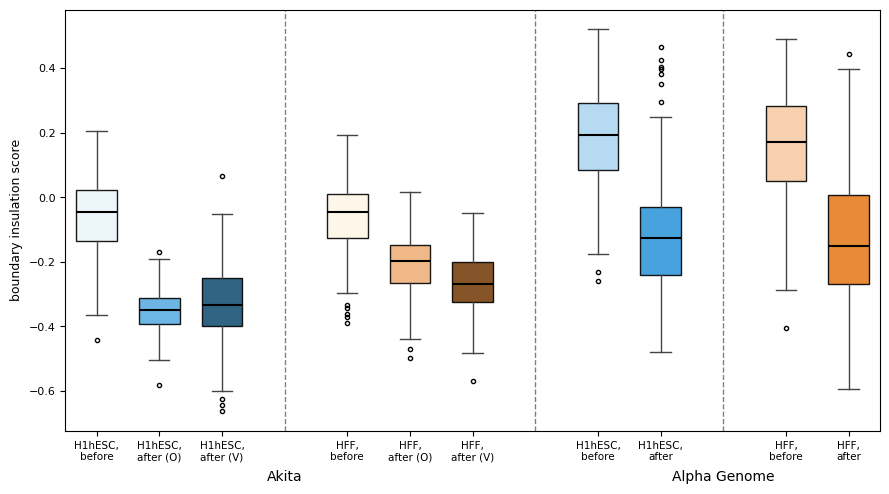

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

positions = [1, 2, 3, 5, 6, 7, 9, 10, 12, 13]

data = [
    df_filt["insul_orig_H1hESC"],
    df_filt["insul_opt_mean_H1hESC"],
    df_filt["insul_heldout_mean_H1hESC"],
    df_filt["insul_orig_HFF"],
    df_filt["insul_opt_mean_HFF"],
    df_filt["insul_heldout_mean_HFF"],
    df_filt["alpha_og_urq_H1hESC"],
    df_filt["alpha_ed_urq_H1hESC"],
    df_filt["alpha_og_urq_HFF"],
    df_filt["alpha_ed_urq_HFF"],
]

colors = (
    COLORS["H1hESC"][:3]          # Akita H1hESC: before, after O, after V
    + COLORS["HFF"][:3]           # Akita HFF:    before, after O, after V
    + COLORS["H1hESC"][3:]        # AG H1hESC:    before, after
    + COLORS["HFF"][3:]           # AG HFF:       before, after
)

bp = ax.boxplot(
    data,
    positions    = positions,
    widths       = 0.65,
    patch_artist = True,
    medianprops  = dict(color="black", linewidth=1.5),
    whiskerprops = dict(color="#444444", linewidth=1.0),
    capprops     = dict(color="#444444", linewidth=1.0),
    flierprops   = dict(marker="o", markersize=3)
)

for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)

# Separators
ax.axvline(x=4,  color="grey", linestyle="--", linewidth=1.0)   # Akita H1hESC | HFF
ax.axvline(x=8,  color="grey", linestyle="--", linewidth=1.0)   # Akita | Alpha Genome
ax.axvline(x=11, color="grey", linestyle="--", linewidth=1.0)   # AG H1hESC | HFF

ax.set_xticks(positions)
ax.set_xticklabels([
    f"{STRONG_CELL_TYPE},\nbefore",
    f"{STRONG_CELL_TYPE},\nafter (O)",
    f"{STRONG_CELL_TYPE},\nafter (V)",
    f"{WEAK_CELL_TYPE},\nbefore",
    f"{WEAK_CELL_TYPE},\nafter (O)",
    f"{WEAK_CELL_TYPE},\nafter (V)",
    f"{STRONG_CELL_TYPE},\nbefore",
    f"{STRONG_CELL_TYPE},\nafter",
    f"{WEAK_CELL_TYPE},\nbefore",
    f"{WEAK_CELL_TYPE},\nafter",
], fontsize=7.5)

# Section labels
ax.text(4,    -0.12, "Akita",         ha="center", fontsize=10, color="black",
        transform=ax.get_xaxis_transform())
ax.text(11, -0.12, "Alpha Genome",  ha="center", fontsize=10, color="black",
        transform=ax.get_xaxis_transform())

ax.set_ylabel("boundary insulation score", fontsize=9)
ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
# plt.savefig(os.path.join(PLOT_DIR, "cross_celltype_boundary_insulation_boxplot.svg"),
#             bbox_inches="tight")

plt.show()